# Graph neural networks for molecules: quick demo

This notebook trains a from-scratch message passing neural network (MPNN) and a graph convolutional network (GCN) on a small, fully offline dataset whose target is an RDKit-computed descriptor. No download is needed. See `scripts/benchmark.py` for the full ESOL benchmark.

In [1]:
from gnn_molecules import (
    rdkit_property_dataset, random_split, Trainer, MPNN, GCN, set_seed,
)
from gnn_molecules.featurize import ATOM_FEATURE_DIM, BOND_FEATURE_DIM

set_seed(0)
dataset = rdkit_property_dataset(target='logp')
train_set, val_set, test_set = random_split(dataset, seed=0)
len(train_set), len(val_set), len(test_set)

(40, 5, 5)

In [2]:
set_seed(0)
mpnn = Trainer(MPNN(ATOM_FEATURE_DIM, BOND_FEATURE_DIM, hidden_dim=64, num_layers=3))
mpnn.fit(train_set, val_set, epochs=60, batch_size=8, verbose=False)
print('MPNN test metrics:', mpnn.evaluate(test_set))

MPNN test metrics: {'rmse': 0.4212902703158108, 'mae': 0.37240670919418334, 'r2': 0.8497872247468294}


In [3]:
set_seed(0)
gcn = Trainer(GCN(ATOM_FEATURE_DIM, hidden_dim=64, num_layers=3))
gcn.fit(train_set, val_set, epochs=60, batch_size=8, verbose=False)
print('GCN test metrics:', gcn.evaluate(test_set))

GCN test metrics: {'rmse': 0.4886659052505429, 'mae': 0.41772602796554564, 'r2': 0.7978991736250262}


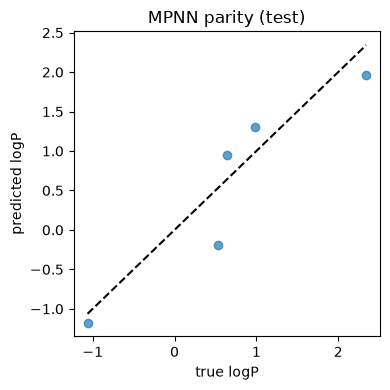

In [4]:
import matplotlib.pyplot as plt

preds = mpnn.predict(test_set)
plt.figure(figsize=(4, 4))
plt.scatter(test_set.targets, preds, alpha=0.7)
lo, hi = test_set.targets.min(), test_set.targets.max()
plt.plot([lo, hi], [lo, hi], 'k--')
plt.xlabel('true logP'); plt.ylabel('predicted logP'); plt.title('MPNN parity (test)')
plt.tight_layout(); plt.show()